 GBM THICKNESS DISTRIBUTION ANALYSIS 

Summary data:
   component_id  mean_thickness_nm  median_thickness_nm  std_thickness_nm  \
0             1         515.043597           510.321656         45.905601   
1             2         448.497180           450.909155         38.208482   
2             1         187.836445           187.919200         27.405206   
3             1         195.308866           193.722710         41.621062   
4             1         165.809201           162.340000         59.453410   

   min_thickness_nm  max_thickness_nm  number_of_measurements patient_id  \
0        424.014140        612.083692                     806      01-24   
1        327.230213        571.887670                     780      01-24   
2         60.402600        267.278924                    1773      01-24   
3         25.974400        285.718400                    1392      01-24   
4          6.493600        297.432400                    1528      01-24   

        image_name  resolut

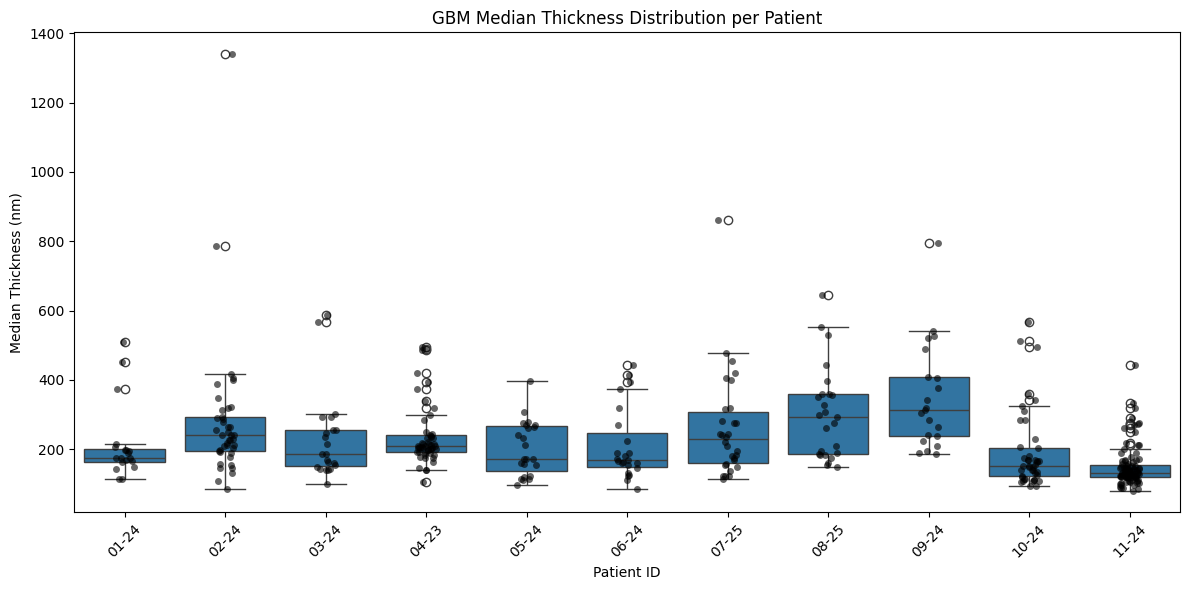

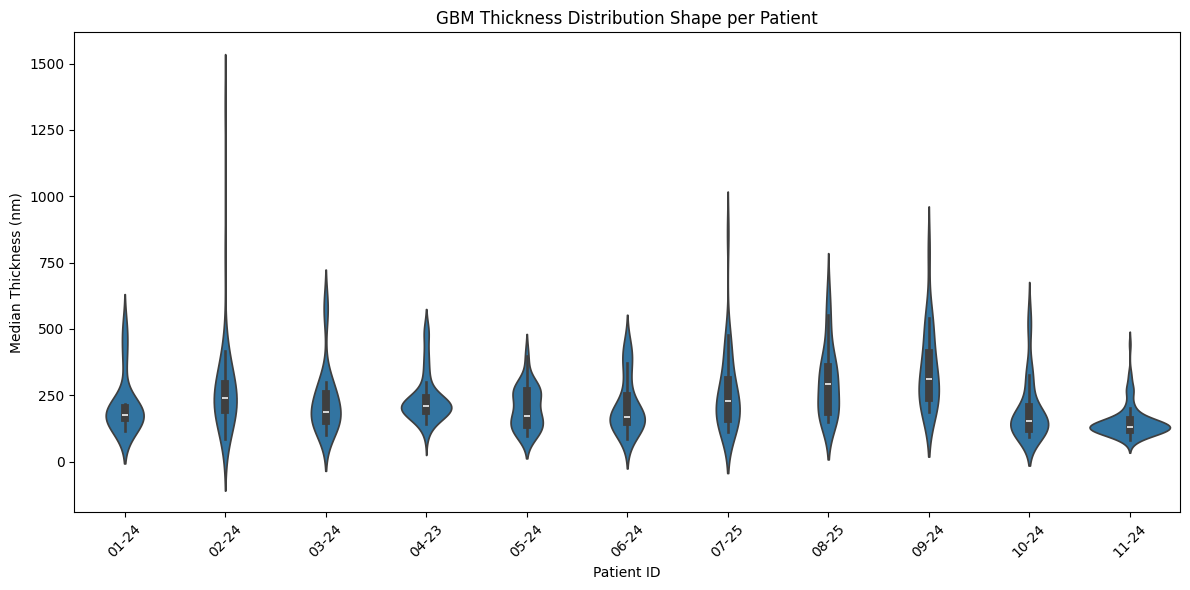

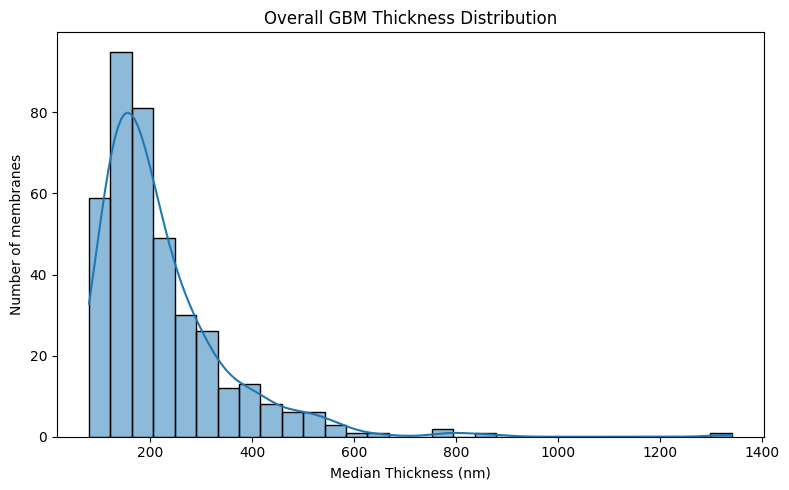

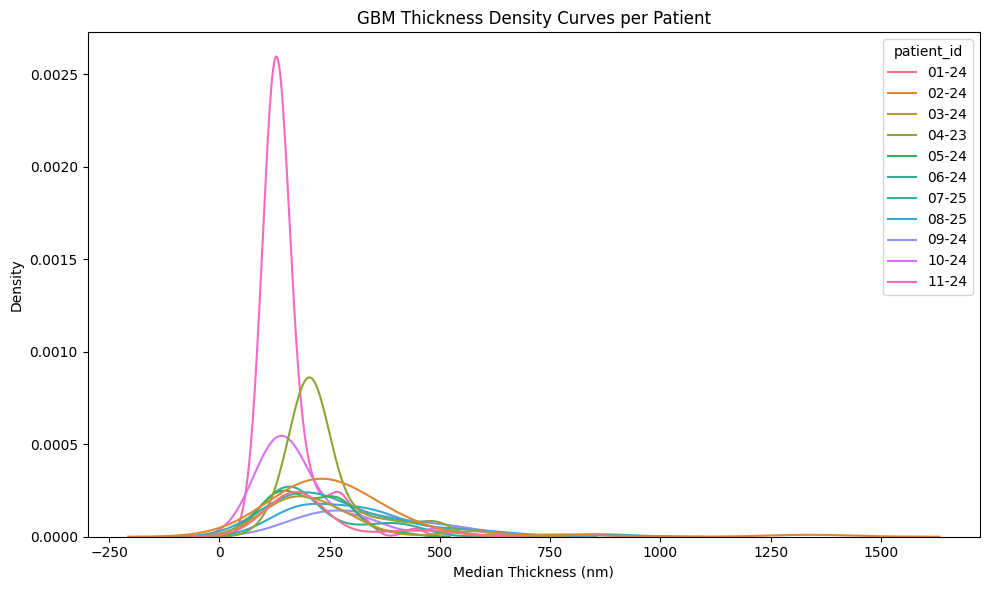

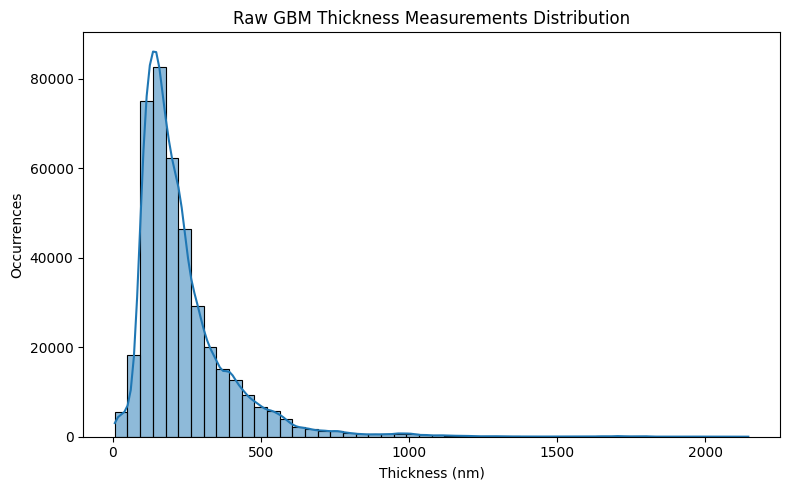


Distribution analysis completed
Number of patients: 11
Number of membrane samples: 394
Number of raw thickness points: 405952

Plots saved in:
C:\Users\ishin\OneDrive\Desktop\ish\GBM_distribution_plots


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SUMMARY_CSV = r"C:\Users\ishin\OneDrive\Desktop\ish\gbm_thickness_summary.csv"
RAW_CSV = r"C:\Users\ishin\OneDrive\Desktop\ish\gbm_raw_thickness.csv"
OUTPUT_FOLDER = r"C:\Users\ishin\OneDrive\Desktop\ish\GBM_distribution_plots"

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)

summary_df = pd.read_csv(
    SUMMARY_CSV
)

raw_df = pd.read_csv(
    RAW_CSV
)

print("="*70)
print(" GBM THICKNESS DISTRIBUTION ANALYSIS ")
print("="*70)
print("\nSummary data:")
print(summary_df.head())
print("\nRaw thickness data:")
print(raw_df.head())


# EXTRACT GLOMERULUS INFORMATION

def extract_glomer(filename):

    name = os.path.splitext(filename)[0]
    parts = name.split("_")

    if len(parts) >= 3:
        return parts[2]
    return "unknown"

summary_df["glomer"] = summary_df["image_name"].apply(
    extract_glomer
)

raw_df["glomer"] = raw_df["image_name"].apply(
    extract_glomer
)

# ============================================================
# 1. PATIENT BOX PLOT
#
# Each point = one membrane component
# ============================================================

plt.figure(
    figsize=(12,6)
)

sns.boxplot(
    data=summary_df,
    x="patient_id",
    y="median_thickness_nm"
)

sns.stripplot(
    data=summary_df,
    x="patient_id",
    y="median_thickness_nm",
    color="black",
    alpha=0.6,
    jitter=True
)

plt.title(
    "GBM Median Thickness Distribution per Patient"
)

plt.xlabel(
    "Patient ID"
)

plt.ylabel(
    "Median Thickness (nm)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "patient_boxplot.png"
    ),
    dpi=300
)
plt.show()


# ============================================================
# 2. VIOLIN PLOT
#
# Shows distribution shape
# ============================================================

plt.figure(
    figsize=(12,6)
)

sns.violinplot(
    data=summary_df,
    x="patient_id",
    y="median_thickness_nm",
    inner="box"
)
plt.title(
    "GBM Thickness Distribution Shape per Patient"
)

plt.xlabel(
    "Patient ID"
)

plt.ylabel(
    "Median Thickness (nm)"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "patient_violinplot.png"
    ),
    dpi=300
)
plt.show()

# ============================================================
# 3. OVERALL MEMBRANE THICKNESS HISTOGRAM
#
# Each membrane = independent sample
# ============================================================

plt.figure(
    figsize=(8,5)
)

sns.histplot(
    data=summary_df,
    x="median_thickness_nm",
    bins=30,
    kde=True
)

plt.title(
    "Overall GBM Thickness Distribution"
)

plt.xlabel(
    "Median Thickness (nm)"
)

plt.ylabel(
    "Number of membranes"
)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "overall_thickness_distribution.png"
    ),
    dpi=300
)
plt.show()

# ============================================================
# 4. PATIENT KDE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10,6)
)

sns.kdeplot(
    data=summary_df,
    x="median_thickness_nm",
    hue="patient_id",
    fill=False
)
plt.title(
    "GBM Thickness Density Curves per Patient"
)
plt.xlabel(
    "Median Thickness (nm)"
)
plt.ylabel(
    "Density"
)

plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "patient_KDE_distribution.png"
    ),
    dpi=300
)
plt.show()


# ============================================================
# 5. RAW THICKNESS DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8,5)
)

sns.histplot(
    data=raw_df,
    x="thickness_nm",
    bins=50,
    kde=True
)

plt.title(
    "Raw GBM Thickness Measurements Distribution"
)
plt.xlabel(
    "Thickness (nm)"
)
plt.ylabel(
    "Occurrences"
)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "raw_thickness_distribution.png"
    ),
    dpi=300
)
plt.show()

#summary
print("\n======================================")
print("Distribution analysis completed")
print("======================================")
print(
    "Number of patients:",
    summary_df["patient_id"].nunique()
)
print(
    "Number of membrane samples:",
    len(summary_df)
)
print(
    "Number of raw thickness points:",
    len(raw_df)
)
print(
    "\nPlots saved in:"
)
print(
    OUTPUT_FOLDER
)